In [1]:
import numpy as np
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sympy import fourier_series, pi
from scipy import stats as st
import scipy.integrate as spi

import sklearn.datasets
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KDTree

from keras.datasets import cifar10
from keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from sklearn.metrics import r2_score


import warnings
warnings.filterwarnings("ignore")

# The idea
We need a kernel that encapsulates relative position and shapes of different matrices to gauge the similarity between them, in 1d vector case euclidean distance was enough for that, an effort to extend it to tensor space;
Suppose the matrix had only one pixel then comparing it with another matrix with one pixel would just be about gauging the distance between them and their values. so to simplify we make a filler kernel (k2d matrix for 1 pixel) that fills the matrix with distance from the pixel, distance will be zero at the coordinate of pixel, then just element wise multiply over the comparing matrix and find the sum, if it is zero, then they are the same matrix else they are dissimilar.

We now extend the idea to multiple pixels and the kernel would be the sum of all the k2d matrices over all the coordinates, they can be weighted by coordinate values to account for value dissimilatrity. This will not give zero  if the same matrix is passed to it as an offset has been introduced at values where pixels are already present, distance is non zero at pixel coordinates due to the presence of other pixels, so we subtract kernel*original_matrix from the final value.

To counter for the assymetry of the simmilarity value we, symmetrically apply the same operation with operands interchanged and the sum is final answer. 

A thing to note, is in this procedure we have autmatically countered the zero matrx giving zero value and other non similar matrices giving same results.

This metric of similarity, surprisingly seems to work regardless of translation and roation of the operand images/matrices, as long as their shape is preserved.

In [2]:


## This Function gives a matrix filled with distances from a cordinate
def k2d(cor,n1,n2,w=1):
    corx,cory = cor
    bb1 = np.ones((1,n1))#.reshape(-1,1).T
    bb2 = np.ones((1,n2))#.reshape(-1,1).T
    b1 = np.arange(0,n1).reshape(-1,1)
    b2 = np.arange(0,n2).reshape(-1,1)
    Y = bb1*b2
    X = b1.T*bb2.T
    return w*((X-corx)**2+(Y-cory)**2)**0.5

## This function gives a matrix that is sum of all the k2d matrices for all the coordinates weighted by the values of the cooridinate
def disKernel(a):
    n1,n2 = a.shape
    ans = np.zeros((n1,n2))
    for i,s in enumerate(a.T):
        for j,d in enumerate(s):
            ans+=k2d([i,j],n2,n1,d)
    return ans

## This function computes the positional/shape seperation of 2 matrices
# the distance is zero regardless of translation and rotation if 2 matrices have same shape of data
# this function also preserves the property of continuity
def distance(a,b):
    kernel = disKernel(a)  
    kernel2 = disKernel(b)  
    return (kernel2*b).sum() + (kernel*b).sum() - (kernel*a).sum() - (kernel2*a).sum()


## These are just random function made for converting the above to a regression model, igonore for now
def coeff(a):
    kernels = [disKernel(i) for i in a]
    kernels_a = [(disKernel(i)*i).sum() for i in a]
    a_ = [i for i in a]
    a__ = sum(a_)/len(a_)
    k_a = sum(kernels_a)/len(kernels_a)
    kernel = sum(kernels)/len(kernels)
    return kernel,k_a,a__
def liner(b,kernel,A,a):
    kernel2 = disKernel(b) 
    return (kernel2*b).sum() + (kernel*b).sum() - A - (kernel2*a).sum()
    
def absol(b):
    z0 = b*0
    o1 = z0 + 1
    return distance(z0,b) #+ distance(o1,b)

In [3]:
## Taking a matrix
a = np.zeros((8,7))
a[4] = 2
a[3][2] = 4

# Another similar one

b = np.zeros((8,7))
b[3] = 1
b[3][1] = 4

# Another one that is rotated version

c = np.zeros((7,8))
c[4] = 2
c[4][-1] = 0
c[3][2] = 4
c = c.T


# Another random one

d = np.zeros((8,7))
d[2] = 3
d[2][2]=4
d[1][1]=5
d[3][6]=8

# Another one that is translated version
e = np.zeros((8,7))
e[5] = 2
e[4][2] = 4

## non 90 degree ratated matrix
dd=np.zeros((8,7))
dd[6][-1] - dd[1][-7]
for x in range(6,-1,-1):
    dd[x][x-7] = 2
dd[-3][-4] = 4
dd = dd


In [4]:
# plotting them


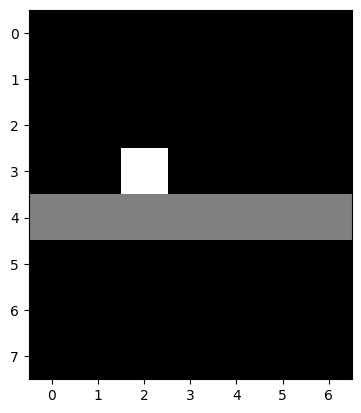

A


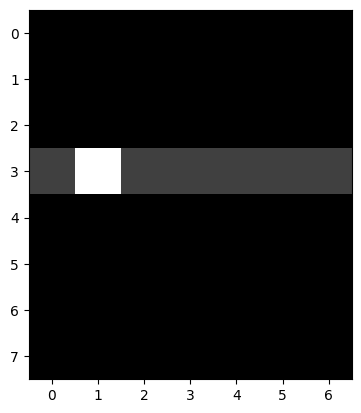

B


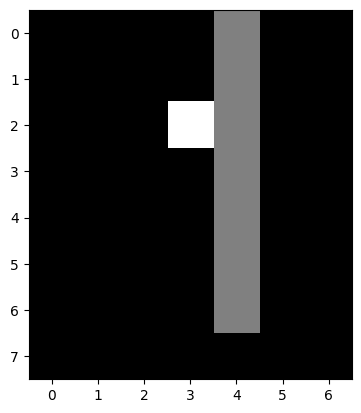

C


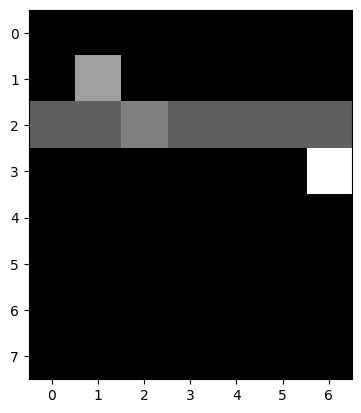

D


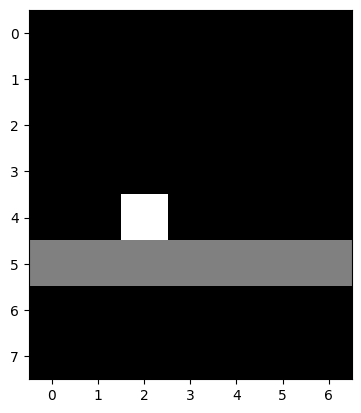

E


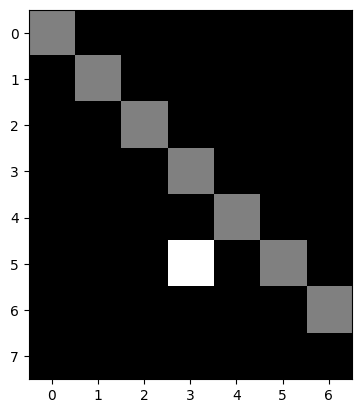

DD


In [5]:
fig = plt.figure
plt.imshow(a, cmap='gray')
plt.show()
print("A")
plt.imshow(b, cmap='gray')
plt.show()
print("B")
plt.imshow(c, cmap='gray')
plt.show()
print("C")
plt.imshow(d, cmap='gray')
plt.show()
print("D")
plt.imshow(e, cmap='gray')
plt.show()
print("E")
plt.imshow(dd, cmap='gray')
plt.show()
print("DD")

In [6]:
## Finding the similarity coefficient distance

In [7]:
li = ["A","B","C","D","E","DD"]
liv = [a,b,c,d,e,dd]
vals = np.array([[round(distance(i,j),4) for j in liv] for i in liv])

print("Similarity distance for all the shapes")
pd.DataFrame(vals,columns = li, index = li,)


Similarity distance for all the shapes


,A,B,C,D,E,DD
A,0.0000,-489.3751,0.0000,2562.6543,-0.0000,288.8622
B,489.3751,0.0000,489.3751,3052.0294,489.3751,778.2374
C,0.0000,-489.3751,0.0000,2562.6543,0.0000,288.8622
D,-2562.6543,-3052.0294,-2562.6543,0.0000,-2562.6543,-2273.7920
E,-0.0000,-489.3751,0.0000,2562.6543,0.0000,288.8622
DD,-288.8622,-778.2374,-288.8622,2273.7920,-288.8622,0.0000


## Conclution
As we can see that A is at distance 0 from C and E as it is just a translated version of it
DD is also rotated version but it is distant to A due to cartetian geometry of the coordinates and euclidean distance used, however it is at the same distance from A, C and E, encapsulating the similar shape and size information, other random shapes, D are huge distant from A.